# Unit End 5: Bank Customer Grievance Analysis

## Problem Scenario

As a data scientist working for the front office of a major American multinational bank, you are responsible for enhancing customer service and ensuring compliance with financial regulations. Your current assignment involves analyzing the customer complaints the bank has received over the past year. The current time-consuming manual process for daily triaging and reviewing of customer complaints. The complaints data is currently underutilized in enhancing the quality of products and services.

### Problem Solution

The goal is to use NLP techniques, such as text classification and sentiment analysis, to efficiently gain insights into the underlying causes of customer grievances. By leveraging these methods, we aim to better understand and address customer grievances, ultimately improving our grievance redressal process.

## Notebook Setup

### Imports

In [2]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Embedding, LSTM,  Dense,  Dropout, Input, Bidirectional
)

import nltk
from nltk.corpus import stopwords, wordnet
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import tokenizers
from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase

stop_words = set(stopwords.words('english'))

np.random.seed(320)
tf.random.set_seed(320)

print("Imports Complete!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Imports Complete!
Pandas version: 3.0.1
NumPy version: 2.4.3
Matplotlib version: 3.10.8
Seaborn version: 0.13.2


### Configuration

In [3]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')
print(gpus)

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        print(f'Using GPU: {gpus[0]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

[]


In [4]:
pd.set_option("display.max_columns", None)

## 1. EDA

### 1.1 Load Data

In [5]:
ISSUES_URL = 'https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit5/Issues.csv'
issues_df = pd.read_csv(ISSUES_URL)
issues_df

,Issue,Issue_ID
0,Closing an account,I_3510635
1,Problem with a credit reporting company's inve...,I_3798538
2,Managing an account,I_3648593
3,Fees or interest,I_6999080
4,Unexpected or other fees,I_2805744
...,...,...
2671,"Application, originator, mortgage broker",I_8327193
2672,"Loan servicing, payments, escrow account",I_9068068
2673,"Loan servicing, payments, escrow account",I_4075987
2674,Incorrect information on credit report,I_2858375


In [6]:
COMPLAINTS_URL = 'https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit5/complaints_banking_2023.csv'
complaints_df = pd.read_csv(COMPLAINTS_URL)
complaints_df

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
0,CID76118977,1/1/2023,Checking or savings account,CASA,NaN,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief
1,CID98703933,1/1/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,NaN
2,CID52036665,1/1/2023,NaN,NaN,NaN,On XX/XX/XX22 I found out that my account was ...,NaN,10466,Closed with monetary relief
3,CID62581335,1/1/2023,Credit card or prepaid card,Credit Cards,I_6999080,NaN,California,92127,Closed with monetary relief
4,CID65731164,1/1/2023,NaN,CASA,I_3648593,NaN,New Jersey,7946,Closed with explanation
...,...,...,...,...,...,...,...,...,...
7006,CID63720677,7/6/2023,Mortgage,Mortgage,I_2806126,I spoke with XXXX XXXX of Capital One in XX/XX...,New York,114XX,NaN
7007,CID93313606,7/6/2023,Mortgage,Mortgage,NaN,NaN,NaN,430XX,Closed with explanation
7008,NaN,7/6/2023,Mortgage,Mortgage,I_4197360,We went to refinance with another company due ...,Maryland,212XX,Closed with explanation
7009,CID32570168,7/6/2023,Credit reporting,Credit Reports,NaN,After XXXX letters mailed to Transunion via ce...,Idaho,836XX,Closed with explanation


In [7]:
DEPT_PRODUCT_URL = 'https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit5/Department_of_Product.csv'
dept_product_df = pd.read_csv(DEPT_PRODUCT_URL)
dept_product_df

,Product,Department
0,Checking or savings account,CASA
1,"Credit reporting, credit repair services, or o...",Credit Reports
2,Credit card or prepaid card,Credit Cards
3,Debt collection,Loans
4,"Money transfer, virtual currency, or money ser...",Remittance
5,Mortgage,Mortgage
6,Vehicle loan or lease,Loans
7,"Payday loan, title loan, or personal loan",Loans
8,Student loan,Loans
9,Credit Card,Credit Cards


In [8]:
DATA_DICT_URL = 'https://media.githubusercontent.com/media/gperdrizet/FSA_devops/refs/heads/main/data/unit5/Data_Dictionary.csv'
data_dict_df = pd.read_csv(DATA_DICT_URL)
data_dict_df

,Field name,Table,Definition
0,Complaint ID,complaints_banking_2023,ID of the complaint
1,Date Received,complaints_banking_2023,Date that the complaint was received by the bank
2,Banking Product,complaints_banking_2023,Bank product involved in complaint
3,Issue ID,complaints_banking_2023,Unique ID for any issue
4,Complaint Description,complaints_banking_2023,Full text of the customer's complaint
5,State,complaints_banking_2023,State (US) of the customer's residence
6,ZIP,complaints_banking_2023,ZIP code of the customer's residence
7,Bank Response,complaints_banking_2023,Bank's response to the customer who filed the ...
8,Banking Product,Department of Product,Bank product involved in complaint
9,Department,Department of Product,Depenartment which caters to specific product ...


A quick glance at **issues_df** we noticed the **issues** column has duplicates, we can check this  for later to consolidate our data and collapsing the **issue_id** column when they could represent the same thing. **data_dict_df** and **dept_product_df** are essentially lookup tables if we need them for reference. Our main dataframe would be **complaints_df** where we already see NaN data and XX for filler characters in zip codes, we will need to handle this later. 
-> *KNN imputing*

### 1.2 Data Quality Assessment

In [9]:
print('Complaints_DF info')
complaints_df.info()
print("\nIsssues_DF info")
issues_df.info()

Complaints_DF info
<class 'pandas.DataFrame'>
RangeIndex: 7011 entries, 0 to 7010
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Complaint ID           5682 non-null   str  
 1   Date Received          5677 non-null   str  
 2   Banking Product        5686 non-null   str  
 3   Department             5676 non-null   str  
 4   Issue ID               5680 non-null   str  
 5   Complaint Description  5681 non-null   str  
 6   State                  5652 non-null   str  
 7   ZIP                    5663 non-null   str  
 8   Bank Response          5682 non-null   str  
dtypes: str(9)
memory usage: 493.1 KB

Isssues_DF info
<class 'pandas.DataFrame'>
RangeIndex: 2676 entries, 0 to 2675
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Issue     2676 non-null   str  
 1   Issue_ID  2676 non-null   str  
dtypes: str(2)
memory usage: 41.9 KB


The dataframes **complaints_df** and **issues_df** both come back with all str dtypes. The **Date Received** column could be converted to a date object as needed. Also we can join the **issues_df** into **complaints_df** on **Issue_ID**.

In [10]:
complaints_df.describe()

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
count,5682,5677,5686,5676,5680,5681,5652,5663,5682
unique,5682,288,17,7,127,5663,54,2990,6
top,CID76118977,4/12/2023,Checking or savings account,CASA,I_3648593,I am filing this complaint because Experian ha...,California,606XX,Closed with explanation
freq,1,49,1357,1329,672,4,1130,33,3971


Observations:
- Interesting to see the number of states being 54? Why is that? other than NaN for missing. Let's find out. 
- Good news is the Complaint_ID has a freq of 1 so no dupes. 
- Complaint Description unique count is lower than the count, why is this? Did 2 users actually write the exact same complaint?

In [63]:
#Convert Date Recieved into a date object
print('Converting Date Received into a Date object...')
complaints_df['Date Received'] = pd.to_datetime(complaints_df['Date Received'], format='%m/%d/%Y')    #This returns as YYYY-mm-dd
print('\nConversion Complete!')

print('\nFetching range of dates...')
min_date = complaints_df['Date Received'].min()
max_date = complaints_df['Date Received'].max()

print(f'\n{min_date} to {max_date}')
print(f'Range: {(max_date - min_date)}')
print('\nDate Range Completed!')

Converting Date Received into a Date object...

Conversion Complete!

Fetching range of dates...

2023-01-01 00:00:00 to 2023-10-21 00:00:00
Range: 293 days 00:00:00

Date Range Completed!


We confirmed we haven't gone outside of our year time gap that we were given.

In [11]:
# Get the value count of states
print("Value Counts of State feature:")
complaints_df.value_counts(["State"])

Value Counts of State feature:


State                               
California                              1130
Florida                                  514
Texas                                    500
New York                                 382
Georgia                                  281
Illinois                                 215
New Jersey                               203
Pennsylvania                             169
North Carolina                           167
Maryland                                 166
Virginia                                 157
Massachusetts                            153
Arizona                                  139
Michigan                                 137
Ohio                                     128
Washington                               121
Tennessee                                100
Nevada                                    83
South Carolina                            78
Connecticut                               71
Colorado                                  62
Missouri          

The reason behind 54 **States** is because of the following not being official "States":
- District of Columbia - this is a federal district under Congress's authority
- UNITED STATES MINOR OUTLYING ISLANDS - are USA island territories in the Pacific Ocean
- Armed Forces Pacifi - is the oldest and largest combatant command (The United States Indo-Pacific Command), based in Hawaii
- Armed Forces Europe - is a mix of national militaries, NATO-aligned forces and developing EU defense structures

In [12]:
#Check for exact duplicated complaints
print("Searching for duplicated Complaints...")

#Get duplicated descriptions
found_dupes = complaints_df[complaints_df.duplicated(subset=["Complaint Description"], keep=False)].dropna(subset=["Complaint Description"])

#Get number of unique complaints
print(f"\nNum of Complaints duplicated: {found_dupes["Complaint Description"].nunique()}")

#Get value counts of complaints
print(f"\nValue counts of dupes:")
print(f"\n{found_dupes.value_counts(subset=["Complaint Description"])}")

#Show duplicated descriptions
print(f"\nNum of rows found: {len(found_dupes)}")
found_dupes

Searching for duplicated Complaints...

Num of Complaints duplicated: 16

Value counts of dupes:

Complaint Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
I am 

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
804,CID98875646,3/1/2023,Debt collection,NaN,I_2549789,this debt is being continually handed to diffe...,Ohio,44122,Closed with explanation
805,CID63285267,NaN,Debt collection,Loans,I_2549789,this debt is being continually handed to diffe...,Ohio,44122,Closed with explanation
1053,CID84977159,3/19/2023,"Credit reporting, credit repair services, or o...",NaN,NaN,I have received multiple mail letters stating ...,NaN,79107,Closed with explanation
1054,CID64893727,NaN,"Credit reporting, credit repair services, or o...",Credit Reports,NaN,I have received multiple mail letters stating ...,NaN,79107,Closed with explanation
1482,CID90107635,4/16/2023,NaN,Credit Cards,I_2805744,Have filed multiple dispute complaints on frau...,California,92543,Closed with explanation
1491,CID65440075,4/16/2023,Credit card or prepaid card,Credit Cards,I_9017186,Have filed multiple dispute complaints on frau...,NaN,92543,Closed with explanation
1887,CID80677737,NaN,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,Bank of ABC is a very reputable bank and has b...,New York,11235,Closed with explanation
1899,CID83924558,NaN,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,Bank of ABC is a very reputable bank and has b...,New York,11235,NaN
2217,CID61882080,6/8/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,""" I am a victim of identity theft. Due to the ...",NaN,89149,Closed with explanation
2289,CID54688656,6/13/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,""" I am a victim of identity theft. Due to the ...",California,90601,Closed with explanation


Observations:
These duplicated complaint descriptions aren't tied to one feature being missing or different there are different discrepancies for each, such as...
- Missing values
- Different dates
- Different zipcode
- Different banking product/department
- Different state

Several of these duplicate descriptions can be combined safely with only missing values. The ones with a later date and all the info the same aside the **Bank Response** feature can be safely combined as well and updated to the most recent date and response. We only want to combine based on **Complaint Descriptions** due to possible customer fragmentation. The same customer can file multiple different complaints, this is fine, but customers purposely skewing the data can be an issue. We would need to address some of these duplicates through a follow-up verification for updates like a different **State** being used, we can not safely handle this on assumptions.

In [13]:
#Get Missing values
print("Finding Missing Data... ")
print("\nNum of missing values per column:")
print(f"{complaints_df.isnull().sum()}")  

#Show percentage of missing values
print("\nPercentage missing values per column:")
print(f"{(complaints_df.isnull().sum() / len(complaints_df)) * 100}")

Finding Missing Data... 

Num of missing values per column:
Complaint ID             1329
Date Received            1334
Banking Product          1325
Department               1335
Issue ID                 1331
Complaint Description    1330
State                    1359
ZIP                      1348
Bank Response            1329
dtype: int64

Percentage missing values per column:
Complaint ID             18.955926
Date Received            19.027243
Banking Product          18.898873
Department               19.041506
Issue ID                 18.984453
Complaint Description    18.970190
State                    19.383825
ZIP                      19.226929
Bank Response            18.955926
dtype: float64


About 20% of data is missing from our dataset

### 1.3 Sampling Assessment

In [14]:
#Sample data for quick assessment
complaints_df.sample(10)

,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response
1588,CID67190583,4/22/2023,NaN,CASA,NaN,Bank of ABC closed my account didnt give me a ...,Alabama,35758,NaN
6182,CID55321464,5/4/2023,Credit reporting,Credit Reports,NaN,XXXX XXXX and XXXX in the Office of Consumer A...,New York,100XX,NaN
4184,NaN,9/26/2023,"Money transfer, virtual currency, or money ser...",Remittance,I_6729142,"Hello! On XX/XX/XX23, I made an international ...",California,90210,Closed with explanation
4514,NaN,1/10/2023,Credit card,Credit Cards,I_5604143,"Thought card was on autopayment, it was not. I...",Colorado,802XX,Closed with explanation
312,CID67434144,1/24/2023,NaN,NaN,I_3798538,I have filed a dispute in regards to the incor...,Nevada,89012,Closed with explanation
4625,CID25003557,1/18/2023,NaN,Loans,NaN,Midland Funding LLC sent false debt collection...,Arizona,853XX,Closed with non-monetary relief
6148,NaN,5/2/2023,Consumer Loan,Loans,I_3778068,This account should it be pay by the loan unem...,Florida,322XX,Closed with explanation
1954,CID57386029,NaN,NaN,NaN,I_4921263,"From my home loan account, Bank Of ABC ( BOA )...",Missouri,64804,Closed with monetary relief
4320,CID69248572,10/6/2023,Checking or savings account,CASA,I_3648593,On XX/XX/XXXX I visited local Bank of ABC bran...,Florida,32714,Closed with monetary relief
1869,CID79623732,5/15/2023,Checking or savings account,CASA,I_3510635,This is regarding closed complaint XXXX. The s...,Illinois,NaN,Closed with monetary relief


Observations:
- There are **complaint description** rows with XXX as filler/redacted words which would require our model to predict the probable next word in sequence.
- These XXX fillers can be found on **other features** as well. Possibly needs to be handled/removed since it acts as a removal.

### 1.4 Dataset combination

In [15]:
print("Joining Datasets...")

#The columns for complaints_df has a space and not an underscore, we are renaming for synchronization and consistency
print("\nRenaming Issue_ID to Issue ID")
issues_df.rename(columns={"Issue_ID":"Issue ID"}, inplace=True)

#Join complaints and issues DF
df_combined = pd.merge(left=complaints_df, right=issues_df, on="Issue ID")

print(f"\nShape of new combination: {df_combined.shape}")

Joining Datasets...

Renaming Issue_ID to Issue ID

Shape of new combination: (5680, 10)


## 2. Preprocessing

In [16]:
print('Preserving combined dataframe, making a copy...')
preprocessing_df = df_combined.copy(deep=True)
preprocessing_df

Preserving combined dataframe, making a copy...


,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response,Issue
0,CID98703933,1/1/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_3798538,There is an item from Bank of ABC on my credit...,California,91344,NaN,Problem with a credit reporting company's inve...
1,CID62581335,1/1/2023,Credit card or prepaid card,Credit Cards,I_6999080,NaN,California,92127,Closed with monetary relief,Fees or interest
2,CID65731164,1/1/2023,NaN,CASA,I_3648593,NaN,New Jersey,7946,Closed with explanation,Managing an account
3,CID85022786,1/1/2023,NaN,Credit Cards,I_2805744,"So, last time I was on the phone with b of a p...",California,NaN,Closed with explanation,Unexpected or other fees
4,CID90664453,1/1/2023,"Credit reporting, credit repair services, or o...",Credit Reports,I_8801555,"Got 5 hard inquiries I dont recognize, from XX...",Arizona,85710,Closed with explanation,Improper use of your report
...,...,...,...,...,...,...,...,...,...,...
5675,NaN,7/5/2023,Credit reporting,Credit Reports,I_9082488,XXXX offered me a pay and delete offer in XXXX...,Pennsylvania,190XX,Closed with explanation,Incorrect information on credit report
5676,CID75752567,7/6/2023,Credit reporting,Credit Reports,I_9082488,NaN,Rhode Island,028XX,Closed with explanation,Incorrect information on credit report
5677,NaN,NaN,Credit card,NaN,I_8552426,"Today, I was issued a XXXX that I did not appr...",Indiana,NaN,Closed with explanation,Transaction issue
5678,CID63720677,7/6/2023,Mortgage,Mortgage,I_2806126,I spoke with XXXX XXXX of Capital One in XX/XX...,New York,114XX,NaN,"Application, originator, mortgage broker"


### 2.1 Clean Text Data

In [17]:
#Create function to use for lemmantizer POS parameter
def get_wordnet_pos(word):
    #Map NLTK tag to WordNet tag.
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN) # Default to noun if no specific tag is found

In [18]:
#Make a function to clean the text data
print("Creating preprocessing() function...\n")
normalizer = normalizers.Sequence([NFD(), StripAccents(), Lowercase()])
lemmatizer = WordNetLemmatizer()

def preprocessing(text:str, view_changes:bool=False):
    '''Clean and tokenize text using using NLTK's recommended word tokenizer.

        Args:
            param1 (str): The text string to be cleaned and tokenized
            param2 (bool): an OPTIONAL print of the changes between each text transformation
    '''

    changes_list = []

    if not isinstance(text, str):
        return []
    changes_list.append(f"Original: {text}")

    # Remove URLs before tokenizing
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    #Normalize text
    text = normalizer.normalize_str(text)
    changes_list.append(f"\nNormalized: {text}")

    # Tokenizer handles: lowercase, @mentions, repeated chars (e.g., sooooo -> sooo)
    tokens = word_tokenize(text)
    changes_list.append(f"\nTokenized: {tokens}")

    # Remove stopwords and single characters
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    changes_list.append(f"\nStopwords Removed: {tokens}")

    # Tokenize and lemmatize with POS tagging
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    changes_list.append(f"\nLemmatized Words: {tokens}")

    # OPTIONAL: Print the changes between each text transformation
    if view_changes:
        [print(change) for change in changes_list]

    return tokens

# For 1 row Testing
preprocessing(preprocessing_df["Complaint Description"][320], True)

Creating preprocessing() function...

Original: A card was issued under my name on XX/XX/XX, however, I did not apply for credit. Im in the process of purchasing a new home and I have not opened any new credit. This fraudulent incident caused my credit score to decline and could ultimately effect my interest rate for the purchase of my new home this is imperative to me. I also, do not understand if I pay XXXX to monitor my credit and my report was and is locked how did this happen? I need to have my name cleared and my credit score restored as soon as possible as I mentioned this will affect the purchase of my new home. Thank you in advance for your prompt attention to this matter.

Normalized: a card was issued under my name on xx/xx/xx, however, i did not apply for credit. im in the process of purchasing a new home and i have not opened any new credit. this fraudulent incident caused my credit score to decline and could ultimately effect my interest rate for the purchase of my new ho

['card',
 'issue',
 'name',
 'xx/xx/xx',
 'however',
 'apply',
 'credit',
 'im',
 'process',
 'purchasing',
 'new',
 'home',
 'open',
 'new',
 'credit',
 'fraudulent',
 'incident',
 'cause',
 'credit',
 'score',
 'decline',
 'could',
 'ultimately',
 'effect',
 'interest',
 'rate',
 'purchase',
 'new',
 'home',
 'imperative',
 'also',
 'understand',
 'pay',
 'xxxx',
 'monitor',
 'credit',
 'report',
 'lock',
 'happen',
 'need',
 'name',
 'clear',
 'credit',
 'score',
 'restore',
 'soon',
 'possible',
 'mention',
 'affect',
 'purchase',
 'new',
 'home',
 'thank',
 'advance',
 'prompt',
 'attention',
 'matter']

In [19]:
# Apply tokenization to entire df
print('Tokenizing preprocessing_df...')
preprocessing_df["Tokens"] = preprocessing_df["Complaint Description"].apply(preprocessing)
preprocessing_df[["Complaint Description", "Tokens"]].head()

Tokenizing preprocessing_df...


,Complaint Description,Tokens
0,There is an item from Bank of ABC on my credit...,"[item, bank, abc, credit, report, belong, must..."
1,NaN,[]
2,NaN,[]
3,"So, last time I was on the phone with b of a p...","[last, time, phone, prepaid, regard, edd, acco..."
4,"Got 5 hard inquiries I dont recognize, from XX...","[get, hard, inquiry, dont, recognize, xxxx, xx..."


### 2.2 Build Vocabulary List

In [20]:
# Build vocabulary
print("Creating Vocabulary list...")
def build_vocab(token_lists, min_freq=2):
    '''Build vocabulary from token lists.'''

    counter = Counter()

    
    for tokens in token_lists:
        counter.update(tokens)

    # Filter by minimum frequency and create vocab
    vocab = {'<PAD>': 0, '<UNK>': 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(preprocessing_df["Tokens"])
print(f'\nVocabulary size: {len(vocab)}')

Creating Vocabulary list...

Vocabulary size: 7099


In [21]:
#Check the length of complaints
lengths = [len(tokens) for tokens in preprocessing_df["Tokens"]]
print("Length Percentiles of Complaints at: 50, 70, 90, 95")
np.percentile(lengths, [50, 75, 90, 95])

Length Percentiles of Complaints at: 50, 70, 90, 95


array([ 56.  , 117.  , 213.  , 296.05])

Looking at our lengths it is safe to say we can use 256 as our max_len.

### 2.3 Create Target Variable

In [22]:
print("Splitting Data for train test split...\n")
# Prepare data
preprocessing_df = preprocessing_df.dropna(subset=['Department'])       #We shouldn't create a fake class
X = preprocessing_df['Complaint Description'].fillna('')
y = preprocessing_df['Department']     #This is a multi-class classification problem

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=320,
    stratify=y
)

# Vectorize text using tf-idf vectorizer
vectorizer = TfidfVectorizer(max_features=20000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')
print(f'Vectorizer X_train shape: {X_train_vec.shape}')
print(f'Vectorizer X_test shape: {X_test_vec.shape}')

Splitting Data for train test split...

Shape of X_train: (3665,)
Shape of X_test: (917,)
Shape of y_train: (3665,)
Shape of y_test: (917,)
Vectorizer X_train shape: (3665, 11504)
Vectorizer X_test shape: (917, 11504)


We learned that Naive Bayes is a good model to use as a baseline expectation. We learned that for TF-IDF inputs we want to take a look at the models **Naive Bayes / SVM / Logistic Regression**. When looking at our shapes of our splits being **5600 samples** it is a very small population and thinking about the complaints we noticed they are clear and explain the issues where we can find **keywords for context**. This leads to what department would most likely be able to help as well. 

## 3. Baseline Designs

### 3.1 Naive Bayes Classifier

In [23]:
model_nb = MultinomialNB()

print('Training Naive Bayes model...')
model_nb.fit(X_train_vec, y_train)

# Predict 
y_pred_nb = model_nb.predict(X_test_vec)

#Evaluate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f'\nNB Accuracy: {accuracy_nb:.3f}')
print('\nNB Classification report:')
print(classification_report(y_test, y_pred_nb))

Training Naive Bayes model...

NB Accuracy: 0.557

NB Classification report:
                precision    recall  f1-score   support

          CASA       0.43      0.93      0.59       213
  Credit Cards       0.54      0.62      0.58       214
Credit Reports       0.85      0.48      0.61       143
         Loans       0.88      0.41      0.56       148
      Mortgage       0.89      0.46      0.61       110
        Others       0.00      0.00      0.00        32
    Remittance       1.00      0.02      0.03        57

      accuracy                           0.56       917
     macro avg       0.66      0.42      0.42       917
  weighted avg       0.67      0.56      0.53       917



c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.p

### 3.2 LSTM Classifier

In [24]:
def tokens_to_indices(tokens_list, vocab, max_len=256):
    '''Convert token lists to padded index sequences.'''

    sequences = []

    for tokens in tokens_list:
        indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
        sequences.append(indices)

    # Pad sequences to max_len
    return pad_sequences(sequences, maxlen=max_len, padding='post', value=vocab['<PAD>'])

print('Converting Tokens to padded index sequences...')

X_train_lstm = tokens_to_indices(X_train, vocab)
X_test_lstm = tokens_to_indices(X_test, vocab)

print(f'\nShape of X_train for LSTM: {X_train_lstm.shape}')
print(f'Shape of X_test for LSTM: {X_test_lstm.shape}')

Converting Tokens to padded index sequences...

Shape of X_train for LSTM: (3665, 256)
Shape of X_test for LSTM: (917, 256)


In [25]:
#Onehot encode the departments 
print('Encoding Departments...')
encoder_one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#Fit transform onehot encoder
y_train_lstm = encoder_one_hot.fit_transform(y_train.values.reshape(-1, 1))
y_test_lstm = encoder_one_hot.fit_transform(y_test.values.reshape(-1, 1))

print(f'\nShape of y_train for LSTM: {y_train_lstm.shape}')
print(f'Shape of y_test for LSTM: {y_test_lstm.shape}')

Encoding Departments...

Shape of y_train for LSTM: (3665, 7)
Shape of y_test for LSTM: (917, 7)


We chose to onehot encode our departments because it is treated as nominal data. Which later decided for us to use categorical cross entrophy for our model's loss.

In [26]:
#Hyperparameters
vocab_size = len(vocab) + 1
embedding_dim = 128
hidden_dim = 128
output_dim = y_test.nunique()       #There are 7 unique departments
dropout = 0.2
activation = "relu"
l2_reg = 1e-4            # L2 regularization strength
learning_rate = 1e-4
max_len = 256

#Model Creation
model_lstm = Sequential([
    Input((max_len,)),
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim,
        mask_zero=True      #Enabled to ignore padding tokens
    ),

    LSTM(hidden_dim),
    
    Dropout(dropout),
    
    Dense((hidden_dim // 2), activation=activation),
    
    Dense(output_dim, activation="softmax", kernel_regularizer=l2(l2_reg))
])

model_lstm.compile(
    loss=keras.losses.CategoricalCrossentropy(name="categorical_crossentropy"),
    optimizer=keras.optimizers.Adam(name="adam", learning_rate=learning_rate),
    metrics=[keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 128)       │       908,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,049,095 (4.00 MB)

 Trainable params: 1,049,095 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Training callbacks
print('Creating Model checkpoints at ./models/')
callbacks = [
    ModelCheckpoint(
        './models/complaint_lstm_classifier.keras',
        save_best_only=True,
        monitor='val_categorical_accuracy',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs/complaint_lstm_classifier',
        histogram_freq=1,
        write_graph=True
    )
]

Creating Model checkpoints at ./models/


In [28]:
print('Balancing class weights...')
class_weights = compute_sample_weight('balanced', y=np.argmax(y_train_lstm, axis=1) )
class_weight_dict = dict(enumerate(class_weights))
print(f'\nClass weights: {class_weight_dict}')

Balancing class weights...

Class weights: {0: np.float64(0.6130812980930077), 1: np.float64(0.6130812980930077), 2: np.float64(0.6138000334952269), 3: np.float64(0.918546365914787), 4: np.float64(0.6130812980930077), 5: np.float64(0.6130812980930077), 6: np.float64(0.887409200968523), 7: np.float64(2.3064820641913153), 8: np.float64(0.6130812980930077), 9: np.float64(0.6130812980930077), 10: np.float64(0.6138000334952269), 11: np.float64(0.6130812980930077), 12: np.float64(1.1845507433742728), 13: np.float64(0.6130812980930077), 14: np.float64(2.3064820641913153), 15: np.float64(0.6138000334952269), 16: np.float64(0.918546365914787), 17: np.float64(0.918546365914787), 18: np.float64(0.6130812980930077), 19: np.float64(0.6130812980930077), 20: np.float64(0.887409200968523), 21: np.float64(0.918546365914787), 22: np.float64(1.1845507433742728), 23: np.float64(1.1845507433742728), 24: np.float64(0.918546365914787), 25: np.float64(1.1845507433742728), 26: np.float64(0.887409200968523), 27

In [29]:
#Train the model
print('Training LSTM model...\n')
history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=5,
    batch_size=8,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Training LSTM model...

Epoch 1/5
458/459 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - categorical_accuracy: 0.1969 - loss: 1.2951
Epoch 1: val_categorical_accuracy improved from None to 0.23337, saving model to ./models/complaint_lstm_classifier.keras

Epoch 1: finished saving model to ./models/complaint_lstm_classifier.keras
459/459 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - categorical_accuracy: 0.2003 - loss: 1.2748 - val_categorical_accuracy: 0.2334 - val_loss: 1.8407
Epoch 2/5
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - categorical_accuracy: 0.2036 - loss: 1.2532
Epoch 2: val_categorical_accuracy did not improve from 0.23337
459/459 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - categorical_accuracy: 0.2079 - loss: 1.2523 - val_categorical_accuracy: 0.2214 - val_loss: 1.8403
Epoch 3/5
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - categorical_accuracy: 0.2044 - loss: 1.2507
Epoch 3: val_categorical_accuracy did not improve from 0.23337
459/459 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - categorical_accuracy: 0.209

We thought of using **LSTM** as our deep learning model, but with something so small we risk **overfitting**, slow training and worse generalization. The LSTM on only 5600 samples is overcomplicated and would most likely benefit from a simpler model, plus since we want to use TF-IDF we would have to pivot and token_to_indice our tokens instead of TF-IDF.

In [30]:
y_pred_lstm = model_lstm.predict(X_test_lstm)
y_pred_lstm_labels = np.argmax(y_pred_lstm, axis=1)

y_test_lstm_labels = np.argmax(y_test_lstm, axis=1)

accuracy_lstm = accuracy_score(y_test_lstm_labels, y_pred_lstm_labels)
print(f"LSTM Accuracy: {accuracy_lstm}")

print("\nLSTM Classification Report:\n")
print(classification_report(y_test_lstm_labels, y_pred_lstm_labels))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
LSTM Accuracy: 0.2202835332606325

LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       213
           1       0.23      0.80      0.36       214
           2       0.00      0.00      0.00       143
           3       0.18      0.21      0.19       148
           4       0.00      0.00      0.00       110
           5       0.00      0.00      0.00        32
           6       0.00      0.00      0.00        57

    accuracy                           0.22       917
   macro avg       0.06      0.14      0.08       917
weighted avg       0.08      0.22      0.11       917



c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gahhh\source\fullstack-projects\fullstack-projects\unit_end_projects\bank_customer_grievance_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.p

### 3.3 SVM Classifier

In [31]:
print("Training SVM model...")

model_svm = LinearSVC(
    C=1.0,              # regularization strength
    class_weight='balanced',  # helps if departments are imbalanced
    max_iter=5000,
    random_state=320
)

model_svm.fit(X_train_vec, y_train)

y_pred_svm = model_svm.predict(X_test_vec)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Accuracy: {accuracy_svm}")

print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

Training SVM model...



SVM Accuracy: 0.653217011995638

SVM Classification Report:

                precision    recall  f1-score   support

          CASA       0.71      0.61      0.66       213
  Credit Cards       0.50      0.81      0.61       214
Credit Reports       0.80      0.64      0.71       143
         Loans       0.77      0.62      0.69       148
      Mortgage       0.82      0.71      0.76       110
        Others       0.60      0.19      0.29        32
    Remittance       0.61      0.49      0.54        57

      accuracy                           0.65       917
     macro avg       0.69      0.58      0.61       917
  weighted avg       0.69      0.65      0.65       917



### 3.4 Confusion Matrices Comparison

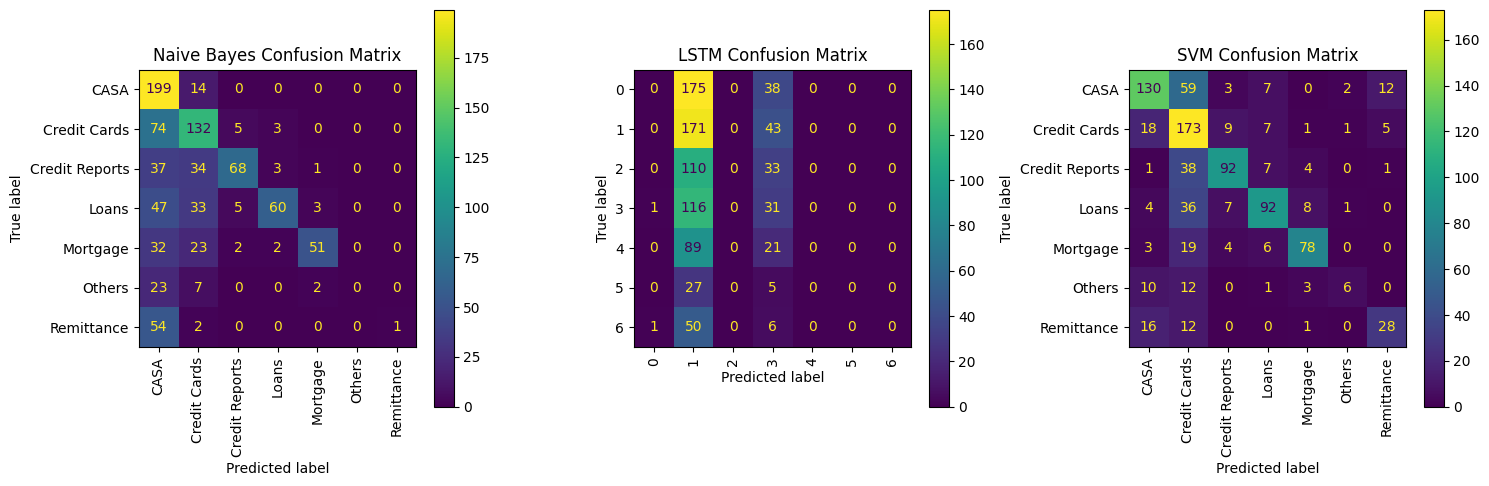

In [32]:
#Plot all models confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].set_title("Naive Bayes Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    xticks_rotation=90,
    ax=ax[0]
)

ax[1].set_title("LSTM Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test_lstm_labels,
    y_pred_lstm_labels,
    xticks_rotation=90,
    ax=ax[1]
)

ax[2].set_title("SVM Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    xticks_rotation=90,
    ax=ax[2]
)

plt.tight_layout()
plt.show()

Comparing our models, we have found that our SVM model handles our data the best with the best accuracy score. Why is that?
- SVMs can support high dimensional sparse TF-IDF matrices very well
- The model also supports smaller datasets way better than a DNN
- The model auto handled class imbalance very well

Our LTSM model in this case was the worse model by far. Why is that?
- Our data is too small for such as complex model, we don't have enough samples to allow the model to fully learn anything
- Class imbalance is very clear here, but we don't think this would make it much better, we attempted to fix it but it skewed to class label 3 rather than 0 and 1
- Embeddings are learning on it's own, our complaints are not long complex examples that the embeddings can learn from

Our Naive Bayes shows a skewed prediction toward the major classes of the population showing the lack of class weight balancing. Since our SVM handles this, that gives the easy edge over our NB model. We can safely say SVM handled this dataset the best, so let's rely on this model for further analysis.

## 4. Sentiment Intensity Design
- Create a SentimentIntensityAnalyzer to predict polarity of complaints as an added feature
- Use best model for implementation

### 4.1 Create Sentiment Feature

In [33]:
print('Creating sentiment scores...')

sia = SentimentIntensityAnalyzer()

#Apply the Sentiment Analyzer to the Complaint Description feature
print('\nApplying Sentiment Analyzer to Complaint Description...')
preprocessing_df['Sentiment'] = (
    preprocessing_df['Complaint Description']
    .fillna('')
    .apply(lambda x: sia.polarity_scores(x)['compound'])
)

preprocessing_df.sample(5)

Creating sentiment scores...

Applying Sentiment Analyzer to Complaint Description...


,Complaint ID,Date Received,Banking Product,Department,Issue ID,Complaint Description,State,ZIP,Bank Response,Issue,Tokens,Sentiment
3114,CID78255861,NaN,NaN,CASA,I_6431567,on XX/XX/23 I received a Bank of ABC email sta...,Illinois,60093,Closed with explanation,Opening an account,"[xx/xx/23, receive, bank, abc, email, state, o...",0.4215
262,CID86098964,1/25/2023,Checking or savings account,CASA,I_6431567,NaN,Texas,76132,Closed with explanation,Opening an account,[],0.0000
1643,CID65564837,NaN,"Credit reporting, credit repair services, or o...",Credit Reports,I_8801555,In accordance with the Fair Credit Reporting a...,South Carolina,29801,Closed with explanation,Improper use of your report,"[accordance, fair, credit, reporting, act, ven...",-0.3798
3987,CID43254135,2/10/2023,Mortgage,Mortgage,I_4197360,If I had XXXX word to describe the experience ...,NaN,805XX,Closed with explanation,"Loan servicing, payments, escrow account","[xxxx, word, describe, experience, far, would,...",-0.8739
270,NaN,1/25/2023,Credit card or prepaid card,Credit Cards,I_2292291,From XXXX XXXX thru XXXX XXXX Bank of ABC allo...,NaN,3583,Closed with monetary relief,Problem with a purchase shown on your statement,"[xxxx, xxxx, thru, xxxx, xxxx, bank, abc, allo...",-0.7121


### 4.2 Train Test Split Data

In [34]:
print("Splitting Data for train test split...")
# Drop missing targets
preprocessing_df = preprocessing_df.dropna(subset=['Department'])

X = preprocessing_df['Complaint Description'].fillna('')
y = preprocessing_df['Department']
sentiment = preprocessing_df['Sentiment']

X_train, X_test, y_train, y_test, senti_train, senti_test = train_test_split(
    X, y, sentiment,
    test_size=0.2,
    random_state=320,
    stratify=y
)

# Vectorize text using tf-idf vectorizer
print('\nVectorizing Complaint feature data...')
vectorizer = TfidfVectorizer(max_features=20000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Convert sentiment to column vector
senti_train = np.array(senti_train).reshape(-1, 1)
senti_test = np.array(senti_test).reshape(-1, 1)

# Combine features
print('\nCombining sentiment data with vectorized data...')
X_train_combined = sp.hstack([X_train_vec, senti_train])
X_test_combined = sp.hstack([X_test_vec, senti_test])

print(f'\nShape of X_train_combined: {X_train_combined.shape}')
print(f'Shape of X_test_combined: {X_test_combined.shape}')

Splitting Data for train test split...

Vectorizing Complaint feature data...

Combining sentiment data with vectorized data...

Shape of X_train_combined: (3665, 11505)
Shape of X_test_combined: (917, 11505)


### 4.3 Train SVM Model 

In [35]:
print("Training SVM model with sentiment feature...")

model_svm_opt = LinearSVC(
    C=1.0,              # regularization strength
    class_weight='balanced',    # helps if departments class imbalance
    max_iter=5000,
    random_state=320
)

model_svm_opt.fit(X_train_combined, y_train)
print('\nTraining Complete!')

Training SVM model with sentiment feature...

Training Complete!


### 4.4 Evaluate Model

In [36]:
#Predict with SVM model 
y_pred_svm_opt = model_svm_opt.predict(X_test_combined)

#Get Accuracy score
accuracy_svm_opt = accuracy_score(y_test, y_pred_svm_opt)
print(f"\nSVM Sentiment Accuracy: {accuracy_svm_opt}")

#Get classification report
print("\nSVM Sentiment Classification Report:\n")
print(classification_report(y_test, y_pred_svm_opt))


SVM Sentiment Accuracy: 0.6521264994547438

SVM Sentiment Classification Report:

                precision    recall  f1-score   support

          CASA       0.72      0.61      0.66       213
  Credit Cards       0.50      0.81      0.62       214
Credit Reports       0.80      0.64      0.71       143
         Loans       0.76      0.62      0.68       148
      Mortgage       0.80      0.71      0.75       110
        Others       0.56      0.16      0.24        32
    Remittance       0.61      0.49      0.54        57

      accuracy                           0.65       917
     macro avg       0.68      0.58      0.60       917
  weighted avg       0.68      0.65      0.65       917



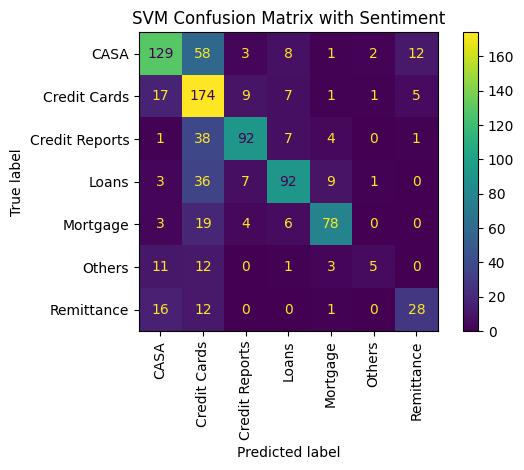

In [37]:
#Plot a confusion matrix with sentiment
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_opt,
    xticks_rotation=90,
)
plt.title('SVM Confusion Matrix with Sentiment')
plt.tight_layout()
plt.show()

Looking at our results, adding **Sentiment** didn't seem to do anything for accuracy for predicting **Departments**. This leads us to understand that departments aren't determined by emotions from **Sentiment**, department predictions care more about keywords i.e. Mortgage, Interest, Credit Report. This tells us the **TF-IDF Vectorizer** handled all the signal needed for predicting. A negative sentiment doesn't change the fact that for mortgage related complaints would still be in that department for answers.

### 4.5 Base vs Sentiment

In [38]:
# BEFORE sentiment
y_pred_svm = model_svm.predict(X_test_vec)

# AFTER sentiment
y_pred_svm_opt = model_svm_opt.predict(X_test_combined)

# Get reports as dictionaries
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
report_svm_opt = classification_report(y_test, y_pred_svm_opt, output_dict=True)

# Convert to DataFrames
df_svm = pd.DataFrame(report_svm).transpose()
df_svm_opt = pd.DataFrame(report_svm_opt).transpose()

# Keep only class rows
classes = y_test.unique()
df_svm = df_svm.loc[classes]
df_svm_opt = df_svm_opt.loc[classes]

# Create comparison table
comparison_df = pd.DataFrame({
    'F1 Before': df_svm['f1-score'],
    'F1 After': df_svm_opt['f1-score'],
    'Precision Before': df_svm['precision'],
    'Precision After': df_svm_opt['precision'],
    'Recall Before': df_svm['recall'],
    'Recall After': df_svm_opt['recall'],
})

# Add improvement column
comparison_df['F1 Improvement'] = comparison_df['F1 After'] - comparison_df['F1 Before']

comparison_df.sort_values(by='F1 Improvement', ascending=False)

,F1 Before,F1 After,Precision Before,Precision After,Recall Before,Recall After,F1 Improvement
Credit Cards,0.614565,0.618117,0.495702,0.498567,0.808411,0.813084,0.003552
Credit Reports,0.713178,0.713178,0.800000,0.800000,0.643357,0.643357,0.000000
Remittance,0.543689,0.543689,0.608696,0.608696,0.491228,0.491228,0.000000
CASA,0.658228,0.656489,0.714286,0.716667,0.610329,0.605634,-0.001739
Loans,0.686567,0.684015,0.766667,0.760331,0.621622,0.621622,-0.002552
Mortgage,0.760976,0.753623,0.821053,0.804124,0.709091,0.709091,-0.007352
Others,0.285714,0.243902,0.600000,0.555556,0.187500,0.156250,-0.041812


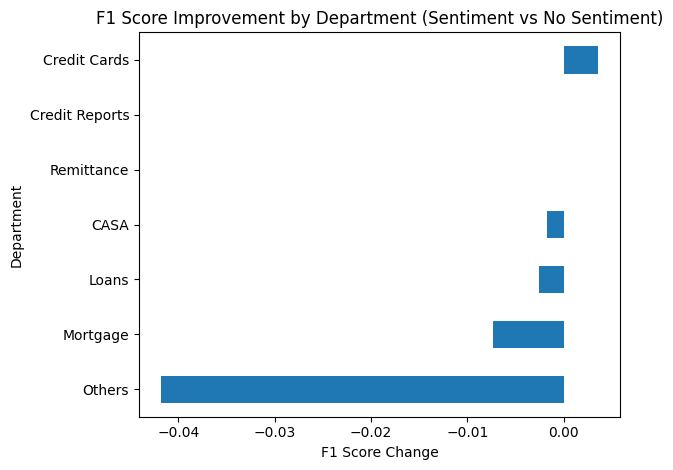

In [39]:
# Sort for visualization
comparison_df_sorted = comparison_df.sort_values(by='F1 Improvement')

#Plot as bar graph
comparison_df_sorted['F1 Improvement'].plot(kind='barh')

plt.title("F1 Score Improvement by Department (Sentiment vs No Sentiment)")
plt.xlabel("F1 Score Change")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [40]:
# Get positive and negative changes 
improved = comparison_df[comparison_df['F1 Improvement'] > 0]
declined = comparison_df[comparison_df['F1 Improvement'] < 0]

print("\nImproved Departments:\n")
print(improved[['F1 Before', 'F1 After', 'F1 Improvement']])

print("\nDeclined Departments:\n")
print(declined[['F1 Before', 'F1 After', 'F1 Improvement']])


Improved Departments:

              F1 Before  F1 After  F1 Improvement
Credit Cards   0.614565  0.618117        0.003552

Declined Departments:

          F1 Before  F1 After  F1 Improvement
CASA       0.658228  0.656489       -0.001739
Mortgage   0.760976  0.753623       -0.007352
Loans      0.686567  0.684015       -0.002552
Others     0.285714  0.243902       -0.041812


### 4.6 Discussion
Adding sentiment feature using **SentimentIntensityAnalyzer** had little to no impact on our classification results. It looks as though it just created noise that may or may not have hurt our data. Complaints are usually of a negative **sentiment** by nature of what a complaint is, so the negative impact on a lot of our departments makes sense. Our **TF-IDF vectorizer** was good enough to figure out and train a majority of learning patterns for our departments. 

As for what the bank can do with this information, they can keep in mind sentiment scores aren't a good determining factor for finding their department, but rather a sense of urgency. **Bank complaints** are not greatly affected by customers emotions, we focus more on **keywords** using TF-IDF to determine a solution. Keep in mind, it is still crucial to find duplicate complaints from some users skewing the data should be handled case by case from possible very emotional customers trying to find a solution.

## 5. Conclusion
In this study of bank customer grievances we navigated through sparse data, invalid entries, redacted text, and duplicate data. This was a showcase of real coarse data of users not entering information correctly as well as incorrect inputs that would bury real intentions. We cleaned the text in complaint descriptions to prep for vectorization. 

We used baseline models to determine what would be best to use for our data. We found that SVM far outperformed our Naive Bayes as well as our LSTM models through class balancing and working well with a small sparse dataset. Confirming this with accuracy metrics, we created a Sentiment feature using nltk's SentimentIntensityAnalyzer to check for more signal for improvement. 

We compared our changes with sentiment to our baseline model without and found there to be no significant changes that would help our model. This proved to us that TF-IDF vectorization created all the signal we needed for our model to perform well outside of hyper tuning for more possibilities.